## Sistema Lineal

In [1]:
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np

In [2]:
from scipy.integrate import odeint ## una alternativa
from scipy.integrate import solve_ivp ## una mejor alternativa

In [3]:
a, b, c, d, = 2, 1, 1, 2

In [26]:
a, b, c, d, = -1, -1, 1, -1 #ejer 2

In [27]:
def dx_dt(t,x):
    dxdt = [a*x[0] + b*x[1] , c*x[0] + d*x[1]]
    return dxdt

def dx_dt_neg(t, x):
    res = dx_dt(t, x)
    return [-res[0], -res[1]]

In [28]:
tf = np.linspace(0, 4, 100)
ic = np.linspace(-10, 10, 10)

In [29]:
X, Y = np.mgrid[-10:10:7j, -10:10:7j] #matriz que tiene 7 puntos entre -10 y 10
u = a*X + b*Y
v = c*X + d*Y

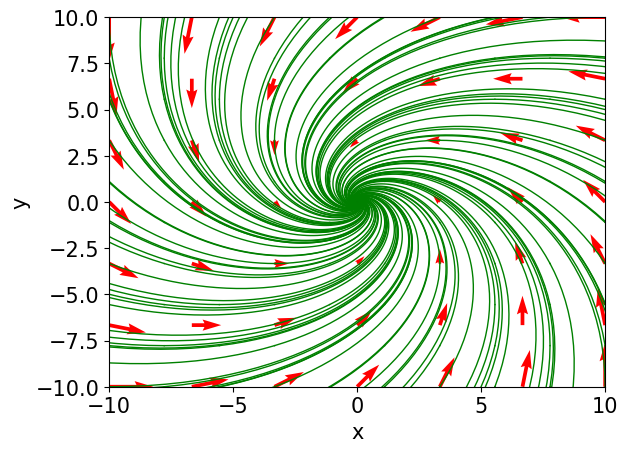

In [30]:
for r in ic:
    for s in ic:
        xsol = solve_ivp(dx_dt, [0, 4], [r,s], t_eval=tf)
        plt.plot(xsol.y.T[:,0], xsol.y.T[:,1], 'g-', linewidth=1)
        xsol = solve_ivp(dx_dt_neg, [0, 4], [r,s], t_eval=tf)
        plt.plot(xsol.y.T[:,0], xsol.y.T[:,1], 'g-', linewidth=1)

plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.tick_params(labelsize=15)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.quiver(X, Y, u, v, color='red')

plt.show()

### Parte dinámica en forma canónica

In [9]:
A = np.array([[2, 1], [1, 2]])
P = np.array([[1, 1], [1, -1]])

L = np.linalg.inv(P) @ A @ P

print(L)

a, b, c, d, = 3, 0, 0, 1

def dx_dt(t,x):
    dxdt = [a*x[0] + b*x[1] , c*x[0] + d*x[1]]
    return dxdt

tf = np.linspace(0, 4, 100)
ic = np.linspace(-2, 2, 10)

X, Y = np.mgrid[-10:10:7j, -10:10:7j]
u = a*X + b*Y
v = c*X + d*Y

[[3. 0.]
 [0. 1.]]


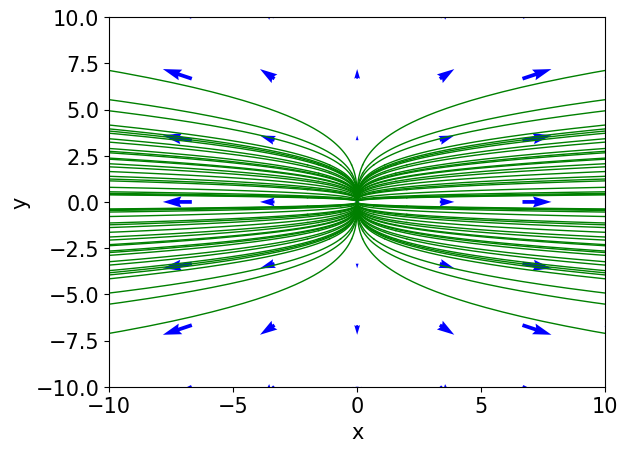

In [10]:
for r in ic:
    for s in ic:
        xsol = solve_ivp(dx_dt, [0, 4], [r,s], t_eval=tf) ## hacia adelant
        plt.plot(xsol.y.T[:,0], xsol.y.T[:,1], 'g-', linewidth=1)
        xsol = solve_ivp(dx_dt_neg, [0, 4], [r,s], t_eval=tf) ## hacia atras
        plt.plot(xsol.y.T[:,0], xsol.y.T[:,1], 'g-', linewidth=1)

plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.tick_params(labelsize=15)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.quiver(X, Y, u, v, color='blue')
plt.show()